# M4A5 - Fundamentos de Modelos Multimodais

Na prática de hoje vamos usar o modelo [CLIP](https://openai.com/index/clip/) da OpenAI.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar o modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to C:\Users\kaiog\AppData\Local\Temp\pip-req-build-kjnax3zc
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369674 sha256=5d0e7d31fc8373c6bc4a69c20846d2ec8d4e8745438605bb3389e2075fce07bc
  Stored in directory: C:\Users\kaiog\AppData\Local\Temp\pip-ephem-wheel-cache-1prqb1p0\wheels\96\4f\3b\3ee9011cf15cdc43dd9e65bdac4faec855ebb4d34beef2f362
Successfully built clip

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   -----------------------------

  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\kaiog\AppData\Local\Temp\pip-req-build-kjnax3zc'


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image

## Utilizar o Modelo

Para isso iremos instanciar o modelo do CLIP e utilizar com texto e imagens.

100%|███████████████████████████████████████| 338M/338M [00:11<00:00, 31.9MiB/s]


['a statue', 'the moutains', 'the beach']
Probabilidades imagem vs. textos: [96.19% de "a statue", 3.79% de "the moutains", 0.01% de "the beach"]


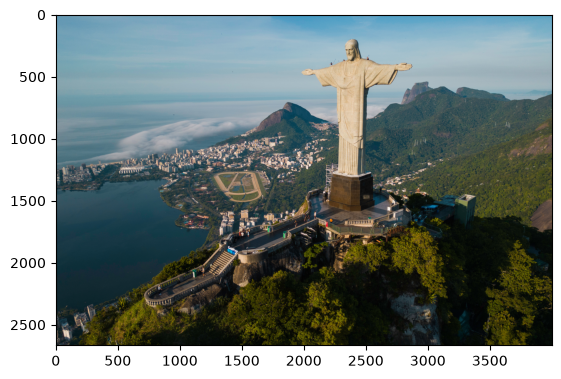

In [3]:
# Path para a imagem.
path_image = "images/rio.jpeg"
# path_image = "images/dog.jpeg"

# Textos para avaliar.
texts = ["a statue", "the moutains", "the beach"]
# texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.
    
    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/openai/CLIP
- https://openai.com/index/clip/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente utilizar outros dados imagens e textos.
- [ ] Tente utilizar outro modelo base do CLIP. Details on https://github.com/openai/CLIP/blob/main/model-card.md#model-versions .

-----------------------------------------------------------------------------------------

In [ ]:
import requests
from io import BytesIO

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
# Path para a imagem.
image = Image.open("images/zelda.jpg").convert("RGB")
image_input = preprocess(image).unsqueeze(0).to(device)

Modelo CLIP

In [11]:
# Modelo CLIP
model, preprocess = clip.load("ViT-B/32", device=device)

# Preprocessamento
image_input = preprocess(image).unsqueeze(0).to(device)

In [36]:

texts = [
    "a screenshot from The Legend of Zelda Ocarina of Time",
    "a screenshot from a video game",
    "Link from a fantasy video game",
    "a mysterious character named Skull Kid in a forest",
]

text_input = clip.tokenize(texts).to(device)

In [37]:
with torch.no_grad():
    logits_per_image, _ = model(image_input, text_input)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]


formated_probs_str = '[' + ', '.join(
    f'{p * 100:.2f}% de "{t}"'
    for p, t in zip(probs, texts)
) + ']'


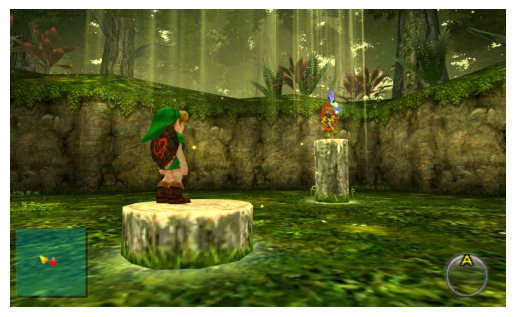

Probabilidades imagem vs textos: [94.62% de "a screenshot from The Legend of Zelda Ocarina of Time", 5.02% de "a screenshot from a video game", 0.02% de "Link from a fantasy video game", 0.32% de "a mysterious character named Skull Kid in a forest"]


In [38]:
plt.imshow(image)
plt.axis("off")
plt.show()

#print(texts) 
print("Probabilidades imagem vs textos:", formated_probs_str)


Tente utilizar outro modelo base do CLIP. Details on https://github.com/openai/CLIP/blob/main/model-card.md#model-versions .

In [39]:
models_to_test = [
    "RN50",
    "RN101",
    "ViT-B/32",
    "ViT-B/16",
    "ViT-L/14"
]

In [41]:
results = {}

for model_name in models_to_test:
    print(f"\n Rodando modelo: {model_name}")

    model, preprocess = clip.load(model_name, device=device)

    image_input = preprocess(image).unsqueeze(0).to(device)
    text_input = clip.tokenize(texts).to(device)

    with torch.no_grad():
        logits_per_image, _ = model(image_input, text_input)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    results[model_name] = probs


 Rodando modelo: RN50

 Rodando modelo: RN101


c:\Users\kaiog\Documents\nexvisual-computer-vision\modulos\.venv\Lib\site-packages\clip\clip.py:57: UserWarning: C:\Users\kaiog/.cache/clip\RN101.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(f"{download_target} exists, but the SHA256 checksum does not match; re-downloading the file")
100%|███████████████████████████████████████| 278M/278M [00:08<00:00, 36.3MiB/s]



 Rodando modelo: ViT-B/32

 Rodando modelo: ViT-B/16


100%|███████████████████████████████████████| 335M/335M [00:06<00:00, 55.1MiB/s]



 Rodando modelo: ViT-L/14


100%|███████████████████████████████████████| 890M/890M [00:12<00:00, 75.9MiB/s]


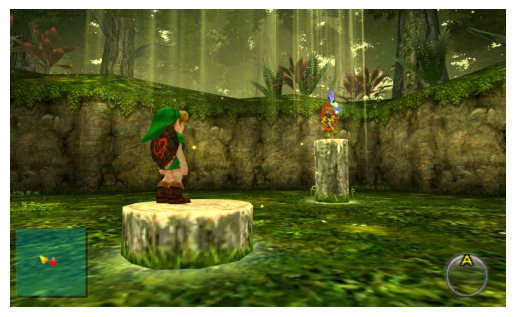


 Modelo: RN50
  94.06% - a screenshot from The Legend of Zelda Ocarina of Time
  3.59% - a screenshot from a video game
  0.15% - Link from a fantasy video game
  2.14% - a mysterious character named Skull Kid in a forest

 Modelo: RN101
  99.06% - a screenshot from The Legend of Zelda Ocarina of Time
  0.07% - a screenshot from a video game
  0.08% - Link from a fantasy video game
  0.80% - a mysterious character named Skull Kid in a forest

 Modelo: ViT-B/32
  94.62% - a screenshot from The Legend of Zelda Ocarina of Time
  5.02% - a screenshot from a video game
  0.02% - Link from a fantasy video game
  0.32% - a mysterious character named Skull Kid in a forest

 Modelo: ViT-B/16
  86.12% - a screenshot from The Legend of Zelda Ocarina of Time
  7.53% - a screenshot from a video game
  0.03% - Link from a fantasy video game
  6.34% - a mysterious character named Skull Kid in a forest

 Modelo: ViT-L/14
  98.75% - a screenshot from The Legend of Zelda Ocarina of Time
  0.13% - a scr

In [47]:
plt.imshow(image)
plt.axis("off")
plt.show()

for model_name, probs in results.items():
    print(f"\n Modelo: {model_name}")
    for t, p in zip(texts, probs):
        print(f"  {p*100:.2f}% - {t}")